# Notebook 18 — Bayesian Optimization Neural Network

**Autor:** Nassim Groppe
**Modul:** DBU Data Analyst I
**Datum:** August 2026

## Zweck

Systematische Hyperparameter-Optimierung des neuronalen Netzes aus Notebook 17 mittels Bayesian Optimization. Ziel: Ausschluss, dass die Baseline-Underperformance auf suboptimale Hyperparameter zurückzuführen ist.

## Methodik

- **Identische Methodik wie in Notebook 15 (Random Forest)**: BayesSearchCV mit TimeSeriesSplit
- **Strikte Trainings-Test-Trennung**: Optimierung ausschließlich auf Trainingsdaten (bis 2023-12-31)
- **Suchraum**: 5 Hyperparameter (Layer-Größen, Learning Rate, L2, Batch-Größe, Aktivierungsfunktion)
- **Iterationen**: 30 Bayesian-Search-Runs mit Gaussian Process
- **Cross-Validation**: 5-fach TimeSeriesSplit (verhindert Look-Ahead-Bias in CV)

## Erwartung

Falls die schwache EMH robust gilt: auch nach systematischer Hyperparameter-Optimierung bleibt die Out-of-Sample-Performance nahe null oder leicht negativ.

In [1]:
# ============================================================
# Imports und globale Konstanten
# ============================================================
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import matplotlib.pyplot as plt
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# STRIKTE HOLD-OUT-TRENNUNG — identisch zu Notebook 15 und 17
TRAIN_END = "2023-12-31"
TEST_START = "2024-01-01"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Feature-Liste — IDENTISCH zu Notebook 15 und 17
FEATURES = [
    'Daily_Return',
    'Momentum_3M', 'Momentum_6M', 'Momentum_12M',
    'Volatility_30d',
    'MA_50', 'MA_200',
    'RSI_14'
]
TARGET = 'Forward_Return_1W'

print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")
print(f"Split: Train bis {TRAIN_END}, Test ab {TEST_START}")

Features: 8
Target: Forward_Return_1W
Split: Train bis 2023-12-31, Test ab 2024-01-01


In [2]:
# ============================================================
# Daten laden — identische Basis wie Notebook 17
# ============================================================
from pathlib import Path

# Projekt-Root robust ermitteln (funktioniert unabhängig vom Kernel-Arbeitsverzeichnis)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "processed").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

basket = pd.read_parquet(PROJECT_ROOT / "data/processed/basket_features.parquet")

# Forward_Return_1W berechnen (identisch zu Notebook 15/17)
basket = basket.sort_values(['Ticker', 'Date']).copy()
basket['Forward_Return_1W'] = (
    basket.groupby('Ticker')['Close']
    .transform(lambda s: s.shift(-5) / s - 1)
)

# NaN-Filter
basket_clean = basket.dropna(subset=FEATURES + [TARGET]).copy()

# Train/Test-Split
train = basket_clean[basket_clean['Date'] <= TRAIN_END].copy()
test = basket_clean[basket_clean['Date'] >= TEST_START].copy()

X_train = train[FEATURES].values
y_train = train[TARGET].values
X_test = test[FEATURES].values
y_test = test[TARGET].values

# Standardisierung (fit NUR auf Training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scaler speichern für Notebook 19
joblib.dump(scaler, PROJECT_ROOT / "models/scaler_nn.pkl")

print(f"Training: {X_train_scaled.shape}")
print(f"Test:     {X_test_scaled.shape}")
print(f"Scaler gespeichert: {PROJECT_ROOT / 'models/scaler_nn.pkl'}")

Training: (81600, 8)
Test:     (38480, 8)
Scaler gespeichert: /Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/models/scaler_nn.pkl


In [3]:
# ============================================================
# Suchraum für Bayesian Optimization
# ============================================================
# Diskrete Kategorien für Hidden-Layer-Größen als String-Keys statt Tupel.
# Grund: skopt (0.10.2) + numpy 2.0 können in Categorical() keine Tupel
# unterschiedlicher Länge verarbeiten (numpy verweigert das ragged Array),
# was BayesSearchCV.fit() mit "Not all points are within the bounds of
# the space." abstürzen lässt. String-Keys umgehen den Bug zuverlässig.

hidden_layer_options = {
    'h32': (32,),
    'h64': (64,),
    'h128': (128,),
    'h64_32': (64, 32),
    'h128_64': (128, 64),
    'h128_64_32': (128, 64, 32),
    'h256_128_64': (256, 128, 64),
    'h64_32_16': (64, 32, 16),
}

search_space = {
    'hidden_layer_sizes': Categorical(list(hidden_layer_options.keys())),
    'learning_rate_init': Real(1e-4, 1e-2, prior='log-uniform'),
    'alpha': Real(1e-5, 1e-2, prior='log-uniform'),  # L2-Regularisierung
    'batch_size': Categorical([32, 64, 128, 256]),
    'activation': Categorical(['relu', 'tanh'])
}

print("Suchraum definiert:")
for param, space in search_space.items():
    print(f"  {param}: {space}")
    

Suchraum definiert:
  hidden_layer_sizes: Categorical(categories=('h32', 'h64', 'h128', ..., 'h128_64_32', 'h256_128_64', 'h64_32_16'), prior=None)
  learning_rate_init: Real(low=0.0001, high=0.01, prior='log-uniform', transform='identity')
  alpha: Real(low=1e-05, high=0.01, prior='log-uniform', transform='identity')
  batch_size: Categorical(categories=(32, 64, 128, 256), prior=None)
  activation: Categorical(categories=('relu', 'tanh'), prior=None)


In [4]:
# ============================================================
# BayesSearchCV Setup
# ============================================================
# TimeSeriesSplit für zeitbewusste Cross-Validation
# (verhindert, dass Trainingsdaten aus der Zukunft für Validation genutzt werden)
tscv = TimeSeriesSplit(n_splits=5)

class MLPRegressorHL(MLPRegressor):
    """MLPRegressor, der für hidden_layer_sizes einen String-Key aus
    hidden_layer_options akzeptiert und ihn zur Fit-Zeit ins echte Tupel
    übersetzt (Workaround für den skopt/numpy-Categorical-Bug oben)."""
    def fit(self, X, y):
        original = self.hidden_layer_sizes
        if isinstance(original, str):
            self.hidden_layer_sizes = hidden_layer_options[original]
        try:
            return super().fit(X, y)
        finally:
            self.hidden_layer_sizes = original

# Base Estimator
base_mlp = MLPRegressorHL(
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE
)

# Bayesian Search
bayes_search = BayesSearchCV(
    estimator=base_mlp,
    search_spaces=search_space,
    n_iter=30,                    # Anzahl Bayesian-Iterationen
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,                    # Alle CPU-Kerne
    random_state=RANDOM_STATE,
    refit=False,                  # Finaler Refit erfolgt manuell mit reinem MLPRegressor (nächste Zelle)
    verbose=1
)

print("BayesSearchCV konfiguriert")
print(f"Iterationen: 30")
print(f"CV: TimeSeriesSplit(n_splits=5)")
print(f"Scoring: neg_mean_squared_error")
print()
print("⚠️  Achtung: Der nächste Schritt (Zelle 6) dauert 20-45 Minuten")

BayesSearchCV konfiguriert
Iterationen: 30
CV: TimeSeriesSplit(n_splits=5)
Scoring: neg_mean_squared_error

⚠️  Achtung: Der nächste Schritt (Zelle 6) dauert 20-45 Minuten


In [5]:
# ============================================================
# Bayesian Search — LANGE LAUFZEIT (20-45 Minuten)
# ============================================================
print("Bayesian Search startet...")
print(f"Startzeit: {time.strftime('%H:%M:%S')}")
print("-" * 55)

t_start = time.time()

bayes_search.fit(X_train_scaled, y_train)

t_elapsed = time.time() - t_start

print("-" * 55)
print(f"Bayesian Search abgeschlossen.")
print(f"Laufzeit: {t_elapsed/60:.1f} Minuten")
print(f"Endzeit: {time.strftime('%H:%M:%S')}")
print()
print("Beste Parameter:")
for param, value in bayes_search.best_params_.items():
    print(f"  {param}: {value}")
print()
print(f"Bester CV-Score (neg MSE): {bayes_search.best_score_:.6f}")
print(f"Bester CV-Score (MSE):     {-bayes_search.best_score_:.6f}")

Bayesian Search startet...
Startzeit: 03:24:26
-------------------------------------------------------
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/util

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/util

Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/util

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/.venv/lib/python3.9/site-packages/sklearn/util

-------------------------------------------------------
Bayesian Search abgeschlossen.
Laufzeit: 6.2 Minuten
Endzeit: 03:30:37

Beste Parameter:
  activation: relu
  alpha: 1e-05
  batch_size: 64
  hidden_layer_sizes: h256_128_64
  learning_rate_init: 0.01

Bester CV-Score (neg MSE): -0.003044
Bester CV-Score (MSE):     0.003044


In [6]:
# ============================================================
# Out-of-Sample Evaluation des besten Modells
# ============================================================
# Finaler Refit mit reinem MLPRegressor (kein Custom-Wrapper) — so bleibt
# die gespeicherte .pkl unabhängig von der Wrapper-Klasse aus Zelle 4 ladbar
# (z.B. in Notebook 19).
best_params = dict(bayes_search.best_params_)
best_params['hidden_layer_sizes'] = hidden_layer_options[best_params['hidden_layer_sizes']]

best_model = MLPRegressor(
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
    **best_params
)
best_model.fit(X_train_scaled, y_train)

# Predictions auf Test-Set
y_pred_test = best_model.predict(X_test_scaled)

# Kennzahlen
r2_oos = r2_score(y_test, y_pred_test)
mse_oos = mean_squared_error(y_test, y_pred_test)
mae_oos = mean_absolute_error(y_test, y_pred_test)
rmse_oos = np.sqrt(mse_oos)

# Naive Baseline
y_naive = np.full_like(y_test, y_train.mean())
r2_naive = r2_score(y_test, y_naive)

print("=" * 55)
print("OUT-OF-SAMPLE EVALUATION — Optimiertes NN")
print("=" * 55)
print(f"R²    (opt. NN):  {r2_oos:>10.6f}")
print(f"R²    (naiv):     {r2_naive:>10.6f}")
print(f"MSE:              {mse_oos:>10.6f}")
print(f"RMSE:             {rmse_oos:>10.6f}")
print(f"MAE:              {mae_oos:>10.6f}")
print()
print("Vergleich zu Notebook 17 (Baseline NN):")
print(f"  Baseline R²:   -0.010672")
print(f"  Optimiert R²:  {r2_oos:.6f}")
print(f"  Verbesserung:  {r2_oos - (-0.010672):.6f}")

# Bestes Modell speichern
joblib.dump(best_model, PROJECT_ROOT / "models/nn_bayes_optimized.pkl")
print()
print(f"Modell gespeichert: {PROJECT_ROOT / 'models/nn_bayes_optimized.pkl'}")

OUT-OF-SAMPLE EVALUATION — Optimiertes NN
R²    (opt. NN):   -0.016763
R²    (naiv):      -0.000024
MSE:                0.002341
RMSE:               0.048381
MAE:                0.034260

Vergleich zu Notebook 17 (Baseline NN):
  Baseline R²:   -0.010672
  Optimiert R²:  -0.016763
  Verbesserung:  -0.006091

Modell gespeichert: /Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/models/nn_bayes_optimized.pkl


Predictions gespeichert: /Users/nassimgroppe/Desktop/DBU_Data_Analyst_Python/data/processed/predictions_nn_bayes_oos.parquet
Shape: (38480, 5)


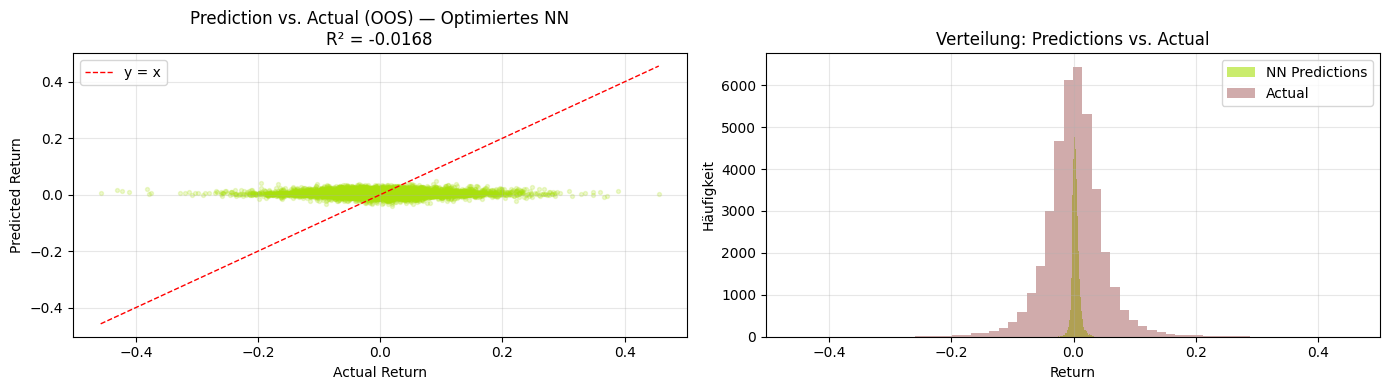

In [7]:
# ============================================================
# Predictions für Notebook 19 speichern
# ============================================================
predictions_nn = test[['Date', 'Ticker', 'Close']].copy()
predictions_nn['Actual_Return'] = y_test
predictions_nn['Predicted_Return_NN'] = y_pred_test
predictions_nn.to_parquet(PROJECT_ROOT / "data/processed/predictions_nn_bayes_oos.parquet", index=False)

print(f"Predictions gespeichert: {PROJECT_ROOT / 'data/processed/predictions_nn_bayes_oos.parquet'}")
print(f"Shape: {predictions_nn.shape}")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=8, color='#A8E00C')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
              'r--', label='y = x', linewidth=1)
axes[0].set_xlabel('Actual Return')
axes[0].set_ylabel('Predicted Return')
axes[0].set_title(f'Prediction vs. Actual (OOS) — Optimiertes NN\nR² = {r2_oos:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Verteilung
axes[1].hist(y_pred_test, bins=60, alpha=0.6, label='NN Predictions', color='#A8E00C')
axes[1].hist(y_test, bins=60, alpha=0.4, label='Actual', color='#8B2E2E')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung: Predictions vs. Actual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

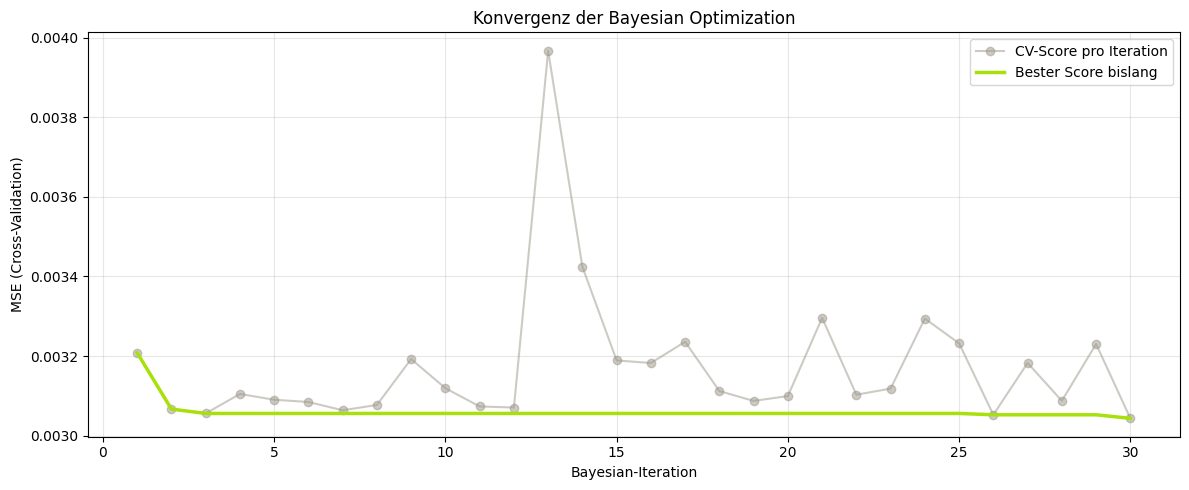

Startpunkt (Iter 1): MSE = 0.003208
Endpunkt (Iter 30): MSE = 0.003044
Verbesserung: 0.000165


In [8]:
# ============================================================
# Konvergenz der Bayesian Optimization
# ============================================================
# CV-Scores über Iterationen
cv_results = pd.DataFrame(bayes_search.cv_results_)

# Beste-bislang-gefundene MSE über Iterationen
mse_scores = -cv_results['mean_test_score'].values
best_so_far = np.minimum.accumulate(mse_scores)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(1, len(mse_scores) + 1), mse_scores,
         'o-', alpha=0.5, color='#9C978A', label='CV-Score pro Iteration')
ax.plot(range(1, len(best_so_far) + 1), best_so_far,
         '-', linewidth=2.5, color='#A8E00C', label='Bester Score bislang')

ax.set_xlabel('Bayesian-Iteration')
ax.set_ylabel('MSE (Cross-Validation)')
ax.set_title('Konvergenz der Bayesian Optimization')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Startpunkt (Iter 1): MSE = {mse_scores[0]:.6f}")
print(f"Endpunkt (Iter {len(mse_scores)}): MSE = {best_so_far[-1]:.6f}")
print(f"Verbesserung: {mse_scores[0] - best_so_far[-1]:.6f}")